## Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import warnings

base_dir = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
warnings.filterwarnings('ignore')

2026-06-09 16:58:19.137904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781024299.360468      98 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781024299.425494      98 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781024299.925202      98 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781024299.925245      98 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781024299.925247      98 computation_placer.cc:177] computation placer alr

## EDA

### Class Distribution

Total number of classes: 15
Total number of images: 20639
                                  Disease Class  Image Count
0         Tomato__Tomato_YellowLeaf__Curl_Virus         3209
1                         Tomato_Bacterial_spot         2127
2                            Tomato_Late_blight         1909
3                     Tomato_Septoria_leaf_spot         1771
4   Tomato_Spider_mites_Two_spotted_spider_mite         1676
5                                Tomato_healthy         1591
6                        Pepper__bell___healthy         1478
7                           Tomato__Target_Spot         1404
8                           Tomato_Early_blight         1000
9                         Potato___Early_blight         1000
10                         Potato___Late_blight         1000
11                Pepper__bell___Bacterial_spot          997
12                             Tomato_Leaf_Mold          952
13                  Tomato__Tomato_mosaic_virus          373
14                         

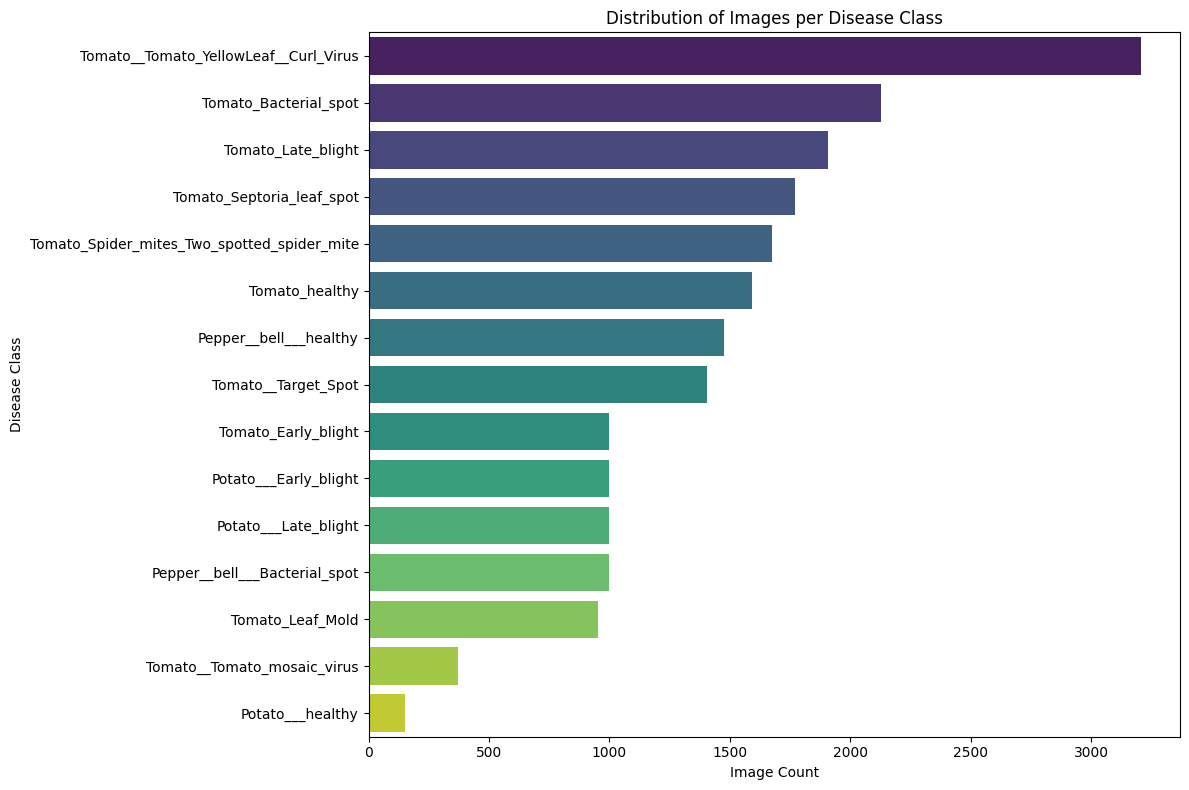

In [2]:
disease_counts = {}
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path): 
        disease_counts[folder] = len(os.listdir(folder_path))

df_counts = pd.DataFrame(list(disease_counts.items()), columns=['Disease Class', 'Image Count'])
df_counts = df_counts.sort_values(by='Image Count', ascending=False).reset_index(drop=True)

print("Total number of classes:", len(df_counts))
print("Total number of images:", df_counts['Image Count'].sum())
print(df_counts.to_string())

plt.figure(figsize=(12, 8))
sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')
plt.title('Distribution of Images per Disease Class')
plt.tight_layout()
plt.show()

### Image Visualization

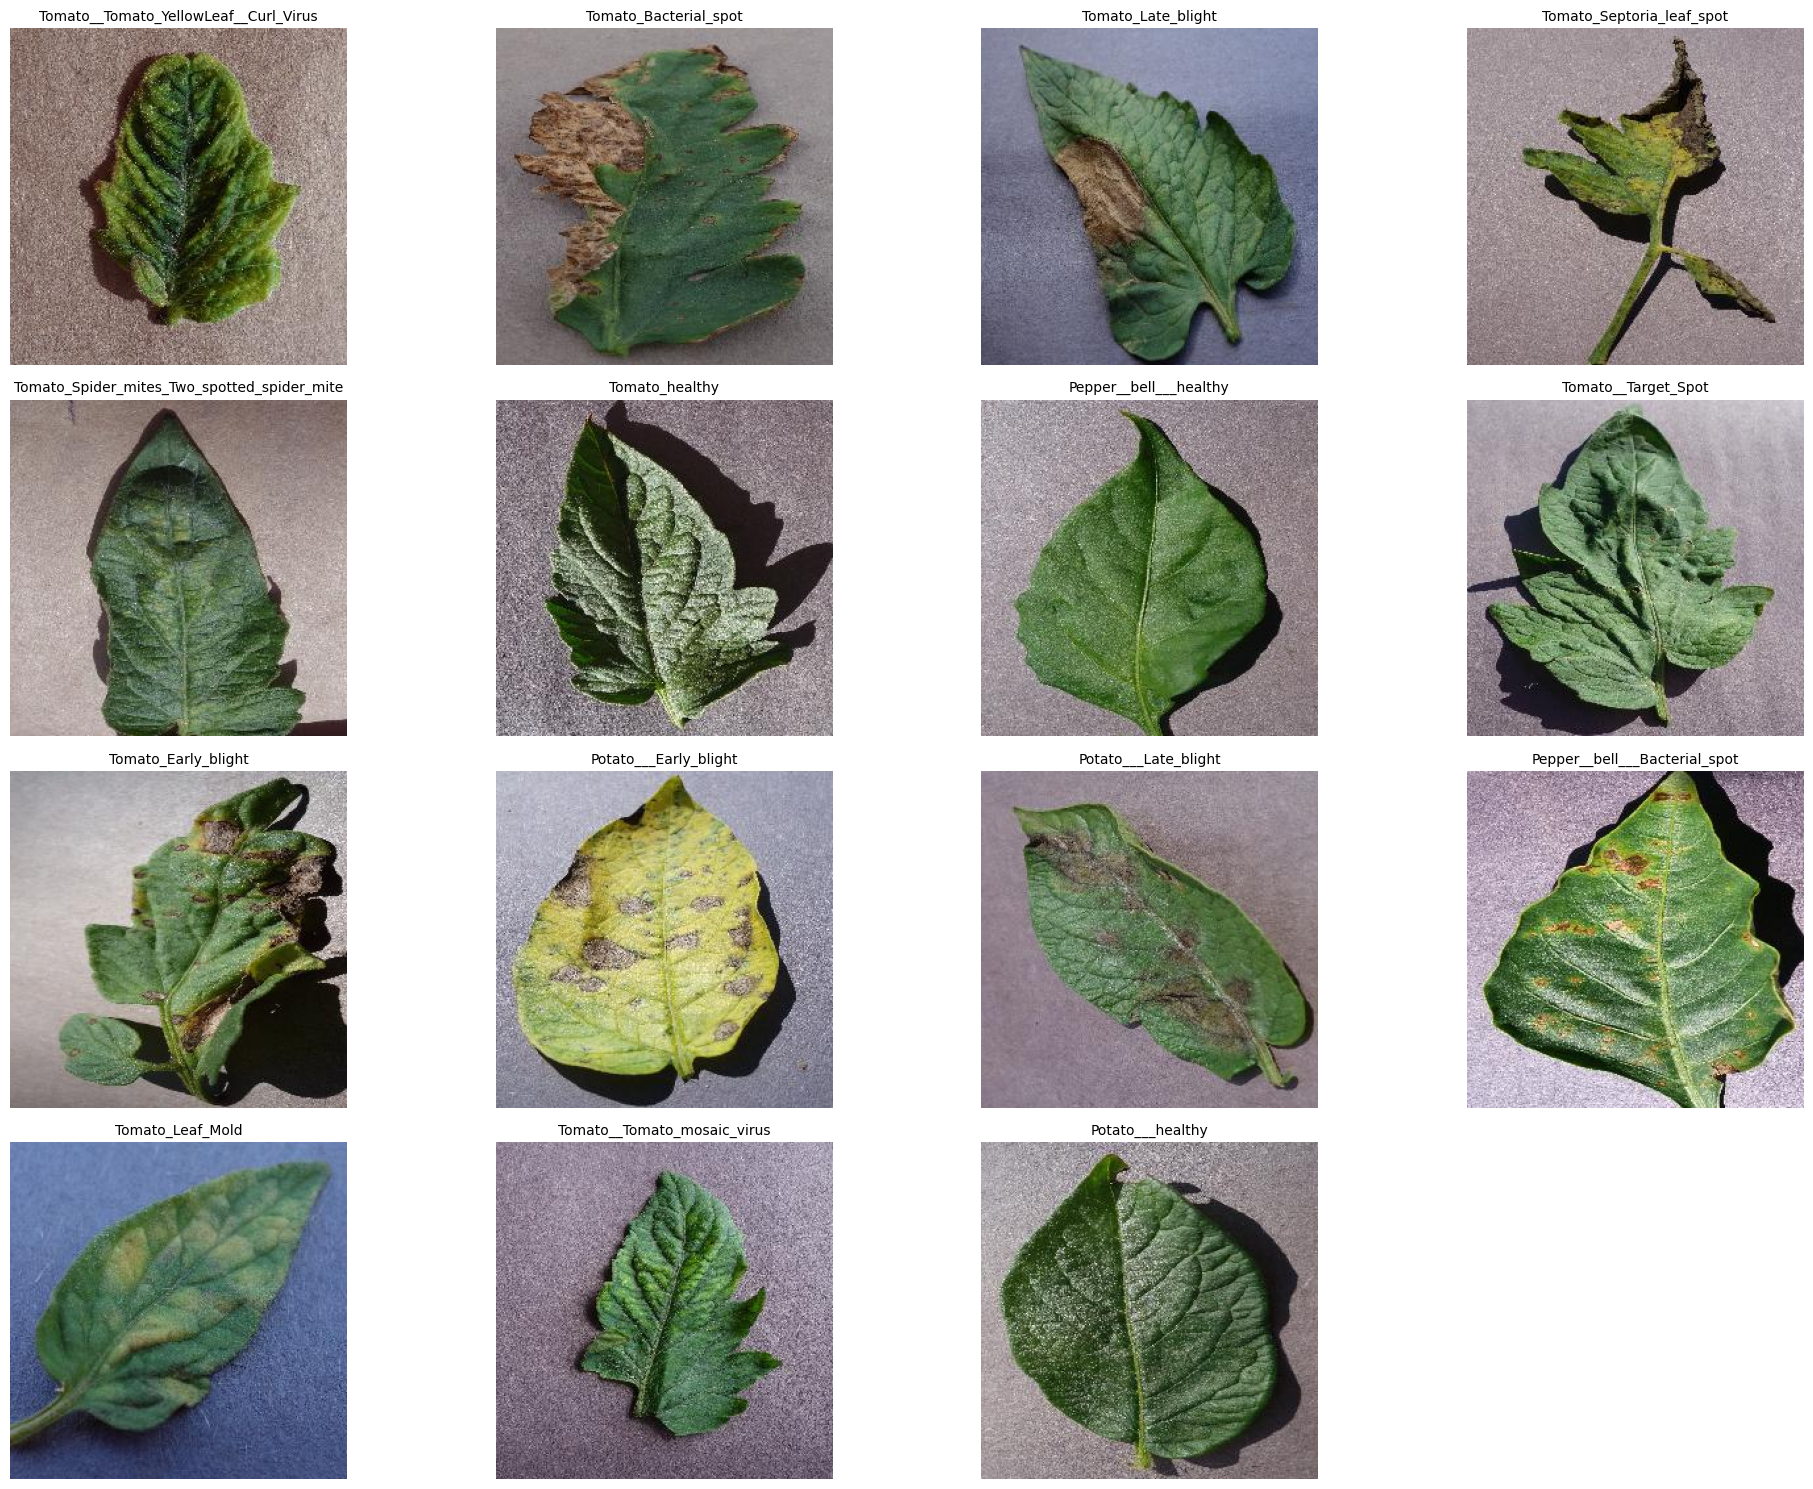

In [3]:
plt.figure(figsize=(20, 15))
for i, folder in enumerate(df_counts['Disease Class']):
    folder_path = os.path.join(base_dir, folder)
    images = os.listdir(folder_path)
    if not images: continue
    sample_img_name = random.choice(images)
    sample_img_path = os.path.join(folder_path, sample_img_name)
    
    img = mpimg.imread(sample_img_path)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(folder, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Loading

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


I0000 00:00:1781024797.665728      98 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781024797.671393      98 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


## Class Imbalance

In [5]:
y_train = np.concatenate([y for x, y in train_dataset], axis=0)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights_array))

## Model Architecture

In [6]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) 
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training

In [7]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_plant_model.keras", 
    save_best_only=True, 
    monitor='val_loss',
    mode='min'
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=3, 
    restore_best_weights=True,
    monitor='val_loss'
)

EPOCHS = 15

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/15


I0000 00:00:1781026104.609481     173 cuda_dnn.cc:529] Loaded cuDNN version 91002


516/516 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.5664 - loss: 1.4363 - val_accuracy: 0.8236 - val_loss: 0.5965
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8184 - loss: 0.5591 - val_accuracy: 0.8454 - val_loss: 0.5045
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.8370 - loss: 0.4845 - val_accuracy: 0.8546 - val_loss: 0.4563
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8474 - loss: 0.4445 - val_accuracy: 0.8682 - val_loss: 0.4227
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8555 - loss: 0.4215 - val_accuracy: 0.8706 - val_loss: 0.4014
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.8599 - loss: 0.4046 - val_accuracy: 0.8818 - val_loss: 0.3662
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.8598 - loss: 0.4078 - val_accuracy: 0.8767 - val_loss: 0.3771
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.8609 - loss: 0.3882 - val_accurac

## Training History

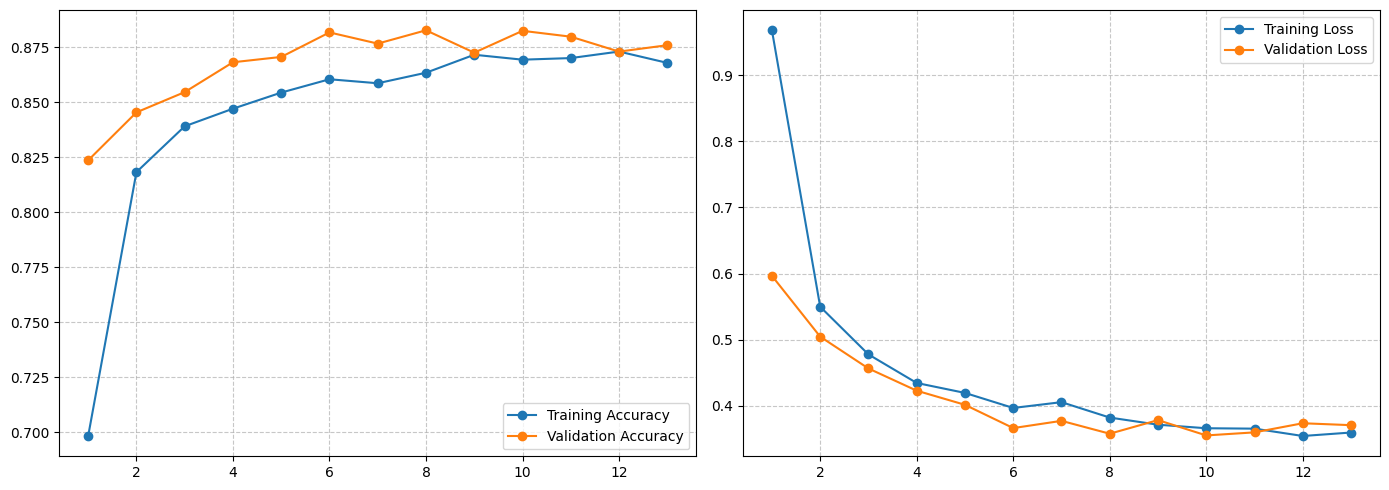

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Fine-Tuning

In [9]:
model.load_weights("best_plant_model.keras")

base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

FINE_TUNE_EPOCHS = 10
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_dataset,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 13/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 69s 107ms/step - accuracy: 0.6444 - loss: 1.4702 - val_accuracy: 0.8498 - val_loss: 0.4723
Epoch 14/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8206 - loss: 0.5162 - val_accuracy: 0.8575 - val_loss: 0.4383
Epoch 15/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8504 - loss: 0.4174 - val_accuracy: 0.8679 - val_loss: 0.3928
Epoch 16/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.8748 - loss: 0.3512 - val_accuracy: 0.8767 - val_loss: 0.3571
Epoch 17/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 54s 104ms/step - accuracy: 0.8865 - loss: 0.3136 - val_accuracy: 0.8977 - val_loss: 0.2989
Epoch 18/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.9016 - loss: 0.2698 - val_accuracy: 0.8866 - val_loss: 0.3165
Epoch 19/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.9116 - loss: 0.2369 - val_accuracy: 0.8939 - val_loss: 0.3033
Epoch 20/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.9187 -

## Final Evaluation

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.98      0.98       200
                     Pepper__bell___healthy       0.98      1.00      0.99       302
                      Potato___Early_blight       0.95      0.99      0.97       189
                       Potato___Late_blight       0.91      0.96      0.94       188
                           Potato___healthy       0.91      0.97      0.94        31
                      Tomato_Bacterial_spot       0.97      0.93      0.95       441
                        Tomato_Early_blight       0.92      0.77      0.84       191
                         Tomato_Late_blight       0.96      0.89      0.93       341
                           Tomato_Leaf_Mold       0.97      0.91      0.94       185
                  Tomato_Septoria_leaf_spot       0.91      0.91      0.91       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.97      0.83

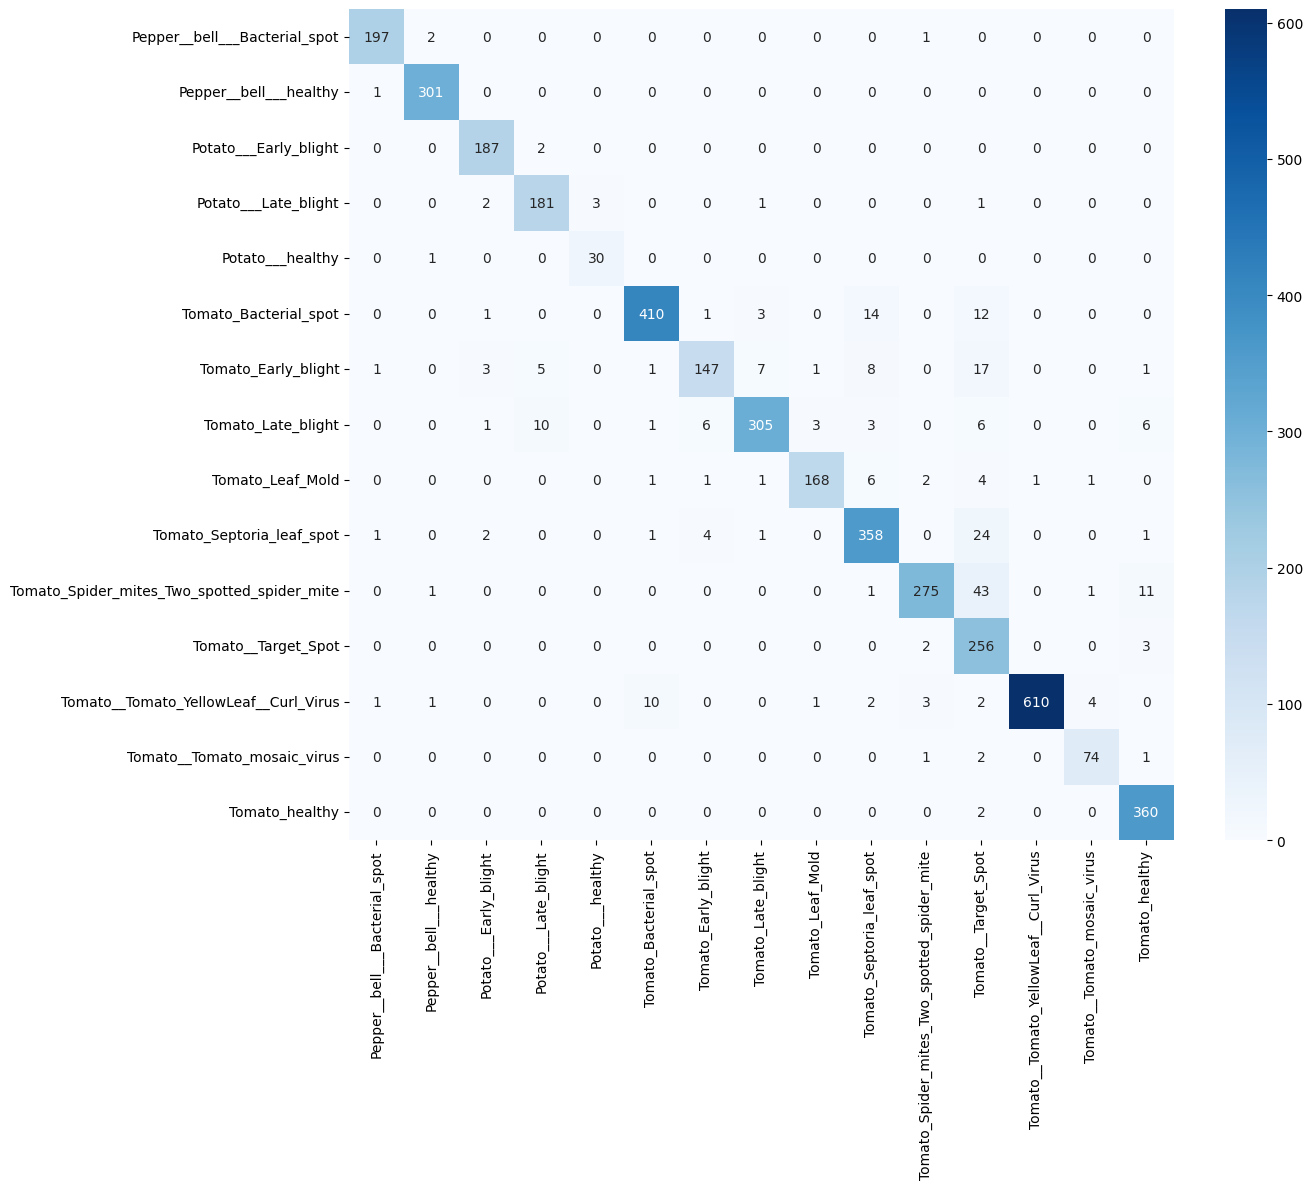

In [10]:
model.load_weights("best_plant_model.keras")

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Saving the  model as well as class name

In [13]:
model.save("plant_disease_model.keras")
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

# Prediction Function

In [15]:

import json

model = tf.keras.models.load_model("plant_disease_model.keras")

with open("class_names.json", "r") as f:
    class_names = json.load(f)

IMG_SIZE = (224, 224)


def predict_disease(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = np.argmax(predictions)

    confidence = np.max(predictions)

    return (
        class_names[predicted_class],
        confidence
    )

# Dictionaries

In [19]:
disease_remedies = {

    "Pepper__bell___Bacterial_spot":
        "Remove infected leaves, avoid overhead irrigation, and apply copper-based bactericides.",

    "Pepper__bell___healthy":
        "No disease detected. Continue proper watering and nutrient management.",

    "Potato___Early_blight":
        "Remove infected foliage, rotate crops, and apply fungicides containing chlorothalonil or mancozeb.",

    "Potato___Late_blight":
        "Destroy infected plants immediately and apply recommended fungicides to prevent spread.",

    "Potato___healthy":
        "No disease detected. Maintain regular crop monitoring.",

    "Tomato___Bacterial_spot":
        "Use disease-free seeds, avoid working with wet plants, and apply copper-based sprays.",

    "Tomato___Early_blight":
        "Prune affected leaves, rotate crops, and use appropriate fungicides.",

    "Tomato___Late_blight":
        "Remove infected plants promptly and apply preventive fungicides.",

    "Tomato___Leaf_Mold":
        "Reduce greenhouse humidity, improve ventilation, and remove infected leaves.",

    "Tomato___Septoria_leaf_spot":
        "Remove infected foliage, mulch around plants, and use approved fungicides.",

    "Tomato___Spider_mites Two-spotted_spider_mite":
        "Use insecticidal soap or miticides and encourage beneficial predators.",

    "Tomato___Target_Spot":
        "Improve airflow around plants and apply fungicides if necessary.",

    "Tomato___Tomato_Yellow_Leaf_Curl_Virus":
        "Control whiteflies using traps or insecticides and remove infected plants.",

    "Tomato___Tomato_mosaic_virus":
        "Remove infected plants and disinfect gardening tools to prevent transmission.",

    "Tomato___healthy":
        "No disease detected. Continue standard crop management practices."
}

In [20]:
disease_info = {

    "Pepper__bell___Bacterial_spot":
        "A bacterial disease causing dark lesions on pepper leaves and fruits.",

    "Pepper__bell___healthy":
        "The pepper leaf appears healthy with no signs of disease.",

    "Potato___Early_blight":
        "A fungal disease caused by Alternaria solani, characterized by concentric rings on older leaves.",

    "Potato___Late_blight":
        "A destructive disease caused by Phytophthora infestans that can rapidly spread under humid conditions.",

    "Potato___healthy":
        "The potato leaf appears healthy with no visible disease symptoms.",

    "Tomato___Bacterial_spot":
        "A bacterial infection that produces small dark spots on leaves and fruits.",

    "Tomato___Early_blight":
        "A fungal disease affecting older tomato leaves, causing target-like lesions.",

    "Tomato___Late_blight":
        "A serious disease caused by Phytophthora infestans that affects leaves, stems, and fruits.",

    "Tomato___Leaf_Mold":
        "A fungal disease favored by high humidity, producing yellow patches on leaves.",

    "Tomato___Septoria_leaf_spot":
        "A fungal disease causing numerous small circular spots with dark margins.",

    "Tomato___Spider_mites Two-spotted_spider_mite":
        "An infestation by tiny pests that feed on plant sap, causing yellow speckling.",

    "Tomato___Target_Spot":
        "A fungal disease characterized by brown lesions with concentric rings.",

    "Tomato___Tomato_Yellow_Leaf_Curl_Virus":
        "A viral disease transmitted by whiteflies that causes yellowing and leaf curling.",

    "Tomato___Tomato_mosaic_virus":
        "A viral disease causing mottled patterns and distortion of tomato leaves.",

    "Tomato___healthy":
        "The tomato leaf appears healthy with no visible disease symptoms."
}

# Interface

In [25]:
import gradio as gr

model = tf.keras.models.load_model("plant_disease_model.keras")

with open("class_names.json", "r") as f:
    class_names = json.load(f)


def predict(image):
    image = image.resize((224, 224))
    image = np.array(image)
    image = np.expand_dims(image, axis=0)

    predictions = model.predict(image, verbose=0)

    predicted_idx = np.argmax(predictions)
    predicted_label = class_names[predicted_idx]
    confidence = float(np.max(predictions))

    return (
        {predicted_label: confidence},
        disease_info[predicted_label],
        disease_remedies[predicted_label]
    )


interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
    gr.Label(label="Prediction"),
    gr.Textbox(label="Disease Information"),
    gr.Textbox(label="Recommended Countermeasures")
    ],
    title="Plant Disease Prediction",
    description="Upload an image of a plant leaf to detect diseases."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7865
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://5b7ba8b44c043a4f97.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error